# Model LP3

Model LP3 extends [Model LP2](GL06LP2.ipynb) from Chapter 5 of {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated` by making government expenditures **endogenous** through a fiscal austerity rule. When the public sector borrowing requirement (PSBR) as a proportion of GDP exceeds a threshold, the government cuts spending. This introduces **hysteresis** — the steady state becomes path-dependent.

## Module Contents

```{eval-rst}
.. toctree::
    :maxdepth: 2

    Variables <GL06LP3/variables.rst>
    Parameters <GL06LP3/parameters.rst>
    Equations <GL06LP3/equations.rst>
    Scenarios <GL06LP3/scenarios.rst>
```

## Key Changes from LP2

Model LP3 differs from [Model LP2](GL06LP2.ipynb) in two respects:

### 1. Endogenous Government Spending (Fiscal Rule)

The government adjusts spending based on the deficit-to-GDP ratio:

```{math}
PSBR(t) = \left(G(t) + r_b(t) \cdot B_s(t-1) + BL_s(t-1)\right)
    - \left(T(t) + r_b(t) \cdot B_{CB}(t-1)\right)
```

When $PSBR(t-1)/Y(t-1) > \text{threshold}$ or $PSBR(t-1)/Y(t-1) < -\text{threshold}$:

```{math}
G(t) = G(t-1) - (z_3 + z_4) \cdot \beta_g \cdot PSBR(t-1)
```

where $z_3 = \mathbb{1}[PSBR/Y > \text{threshold}]$ and $z_4 = \mathbb{1}[PSBR/Y < -\text{threshold}]$.

### 2. New Parameters

| Parameter | Notation | Default | Description |
|-----------|----------|---------|-------------|
| FiscalAdjustmentSpeed | $\beta_g$ | 0.01 | Speed of fiscal adjustment |
| PSBRThreshold | threshold | 0.03 | Deficit-to-GDP trigger |

### Transaction Flow Matrix

```{csv-table} Accounting Transaction Matrix for Model LP3
:file: GL06LP3/transaction_matrix.csv
:header-rows: 2
:stub-columns: 1
```

### Balance Sheet Matrix

```{csv-table} Balance Sheet for Model LP3
:file: GL06LP3/balance_sheet.csv
:header-rows: 2
:stub-columns: 1
```

## Model Dynamics

### Preparatory Steps

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import logging
import sys

from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter

from macrostat.models.GL06LP3 import GL06LP3, ParametersGL06LP3, ScenariosGL06LP3

plt.style.use("../../macrostat.mplstyle")
importlib.reload(logging)
logging.basicConfig(stream=sys.stdout, level=logging.INFO)

### Convergence to the Steady State

Note that in LP3, government spending adjusts endogenously. The initial G=20 is modified by the fiscal rule so that the PSBR converges toward zero.

In [2]:
params = ParametersGL06LP3(
    hyperparameters={"timesteps": 100, "timesteps_initialization": 1}
)
model = GL06LP3(parameters=params)
model.simulate()
output = model.variables.to_pandas()

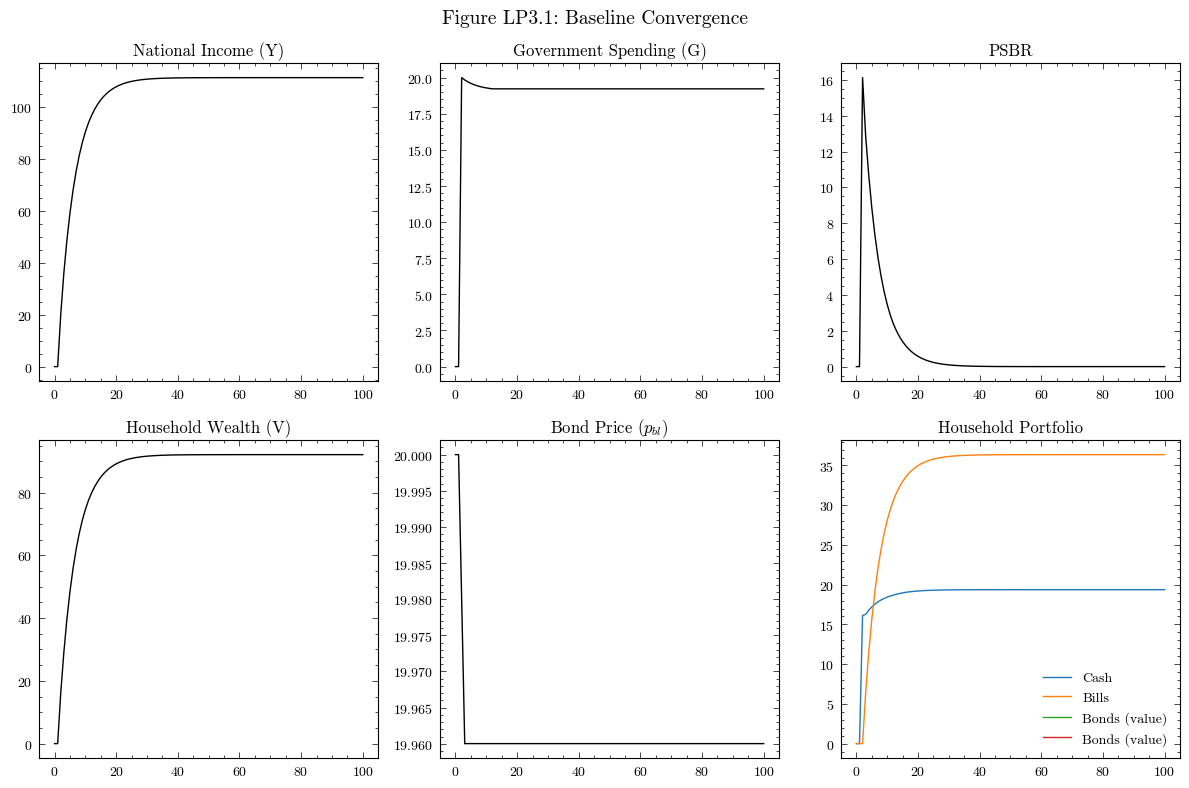

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle("Figure LP3.1: Baseline Convergence", fontsize=14)

axes[0, 0].plot(output.index, output["NationalIncome"], color="k")
axes[0, 0].set_title("National Income (Y)")

axes[0, 1].plot(output.index, output["ConsumptionGovernment"], color="k")
axes[0, 1].set_title("Government Spending (G)")

axes[0, 2].plot(output.index, output["PublicSectorBorrowingRequirement"], color="k")
axes[0, 2].set_title("PSBR")

axes[1, 0].plot(output.index, output["Wealth"], color="k")
axes[1, 0].set_title("Household Wealth (V)")

axes[1, 1].plot(output.index, output["BondPrice"], color="k")
axes[1, 1].set_title("Bond Price ($p_{bl}$)")

axes[1, 2].plot(output.index, output["HouseholdCashStock"], label="Cash")
axes[1, 2].plot(output.index, output["HouseholdBillStock"], label="Bills")
axes[1, 2].plot(
    output.index,
    output["HouseholdBondStock"] * output["BondPrice"],
    label="Bonds (value)",
)
axes[1, 2].set_title("Household Portfolio")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

### Perturbation 1: Drop in Propensity to Consume

Following Section 5.9 of {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated`, we reduce the propensity to consume out of income $\alpha_1$ by 0.1. This triggers a recession that increases the deficit, causing the fiscal austerity rule to kick in and cut government spending.

In [4]:
scenarios = ScenariosGL06LP3(parameters=params)
sc1 = scenarios.get_scenario_index("Scenario.1: Drop in alpha1")
model1 = GL06LP3(parameters=params, scenarios=scenarios)
model1.simulate(scenario=sc1)
output_sc1 = model1.variables.to_pandas()

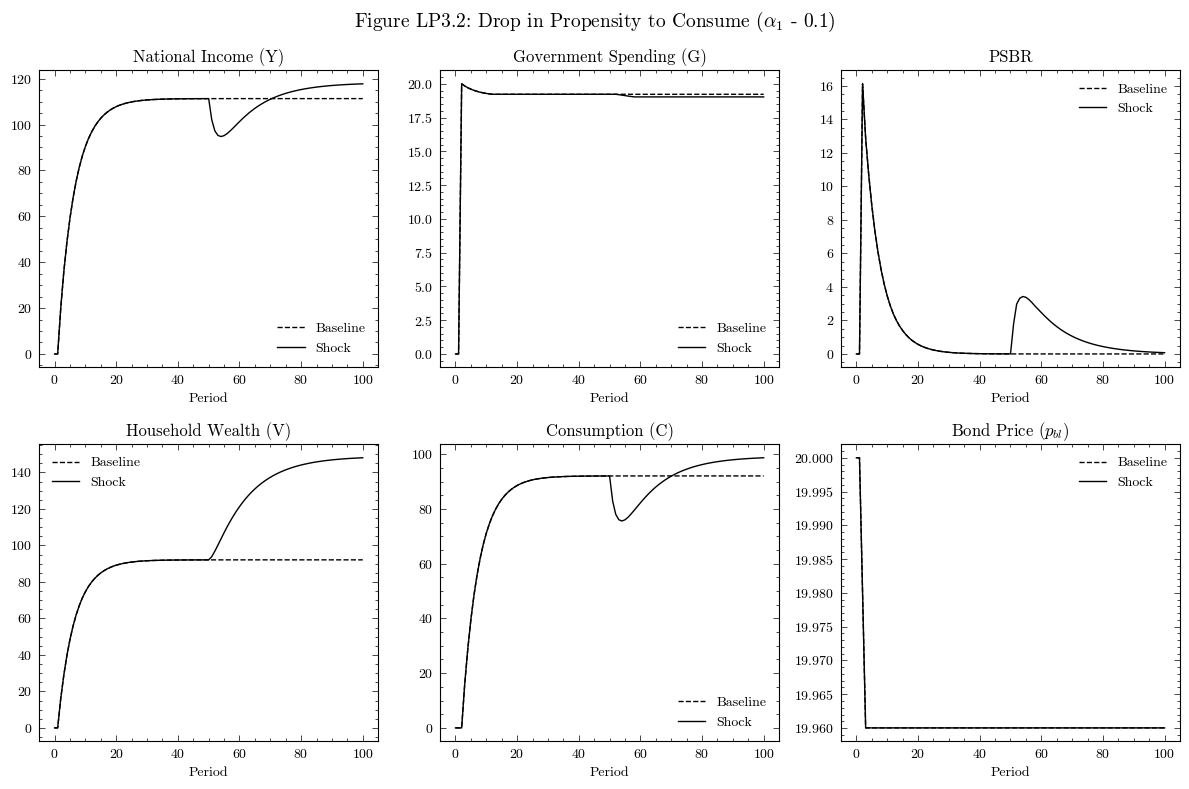

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle("Figure LP3.2: Drop in Propensity to Consume ($\\alpha_1$ - 0.1)", fontsize=14)

for ax in axes.flat:
    ax.set_xlabel("Period")

axes[0, 0].plot(output.index, output["NationalIncome"], "k--", label="Baseline")
axes[0, 0].plot(output_sc1.index, output_sc1["NationalIncome"], "k-", label="Shock")
axes[0, 0].set_title("National Income (Y)")
axes[0, 0].legend()

axes[0, 1].plot(output.index, output["ConsumptionGovernment"], "k--", label="Baseline")
axes[0, 1].plot(output_sc1.index, output_sc1["ConsumptionGovernment"], "k-", label="Shock")
axes[0, 1].set_title("Government Spending (G)")
axes[0, 1].legend()

axes[0, 2].plot(output.index, output["PublicSectorBorrowingRequirement"], "k--", label="Baseline")
axes[0, 2].plot(output_sc1.index, output_sc1["PublicSectorBorrowingRequirement"], "k-", label="Shock")
axes[0, 2].set_title("PSBR")
axes[0, 2].legend()

axes[1, 0].plot(output.index, output["Wealth"], "k--", label="Baseline")
axes[1, 0].plot(output_sc1.index, output_sc1["Wealth"], "k-", label="Shock")
axes[1, 0].set_title("Household Wealth (V)")
axes[1, 0].legend()

axes[1, 1].plot(output.index, output["ConsumptionHousehold"], "k--", label="Baseline")
axes[1, 1].plot(output_sc1.index, output_sc1["ConsumptionHousehold"], "k-", label="Shock")
axes[1, 1].set_title("Consumption (C)")
axes[1, 1].legend()

axes[1, 2].plot(output.index, output["BondPrice"], "k--", label="Baseline")
axes[1, 2].plot(output_sc1.index, output_sc1["BondPrice"], "k-", label="Shock")
axes[1, 2].set_title("Bond Price ($p_{bl}$)")
axes[1, 2].legend()

plt.tight_layout()
plt.show()